In [1]:
!pip install -q scikit-learn pandas matplotlib

In [2]:
# Ignora alguns avisos para deixar a saída do notebook mais limpa
import warnings
warnings.filterwarnings("ignore")

# Manipulação de dados
import pandas as pd

# Gráficos
import matplotlib.pyplot as plt

# Base Wine Dataset
from sklearn.datasets import load_wine

# Normalização dos dados
from sklearn.preprocessing import StandardScaler

# Modelos de agrupamento
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Redução de dimensionalidade para visualização
from sklearn.decomposition import PCA

# Métrica de avaliação para agrupamento
from sklearn.metrics import silhouette_score

# Matriz de comparação com as classes reais, apenas para análise final
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Carrega a base Wine
wine = load_wine()

# Cria um DataFrame com os atributos químicos
dados = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Guarda as classes reais apenas para comparação final
classes_reais = wine.target

# Mostra as primeiras linhas da base
dados.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
print("Quantidade de registros:", dados.shape[0])
print("Quantidade de atributos:", dados.shape[1])
print("Classes reais:", wine.target_names)

Quantidade de registros: 178
Quantidade de atributos: 13
Classes reais: ['class_0' 'class_1' 'class_2']


In [5]:
dados.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
# Cria o normalizador
normalizador = StandardScaler()

# Aplica a normalização nos atributos
X_normalizado = normalizador.fit_transform(dados)

# Visualiza as cinco primeiras linhas normalizadas
pd.DataFrame(X_normalizado, columns=wine.feature_names).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


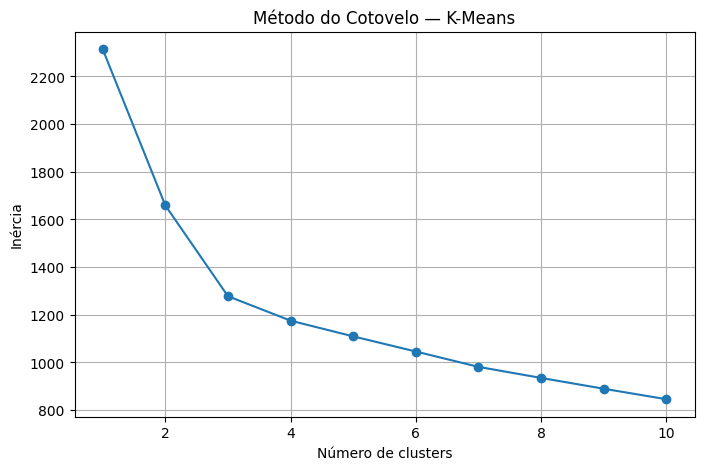

In [7]:
inercia = []

# Testa valores de k de 1 até 10
for k in range(1, 11):
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_normalizado)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inercia, marker="o")
plt.title("Método do Cotovelo — K-Means")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.grid(True)
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Cria uma cópia da base para armazenar os resultados
resultado = dados.copy()

# Treina o modelo e gera os clusters
resultado["Cluster_KMeans"] = kmeans.fit_predict(X_normalizado)

resultado[["Cluster_KMeans"]].head()

,Cluster_KMeans
0,2
1,2
2,2
3,2
4,2


In [9]:
score_kmeans = silhouette_score(
    X_normalizado,
    resultado["Cluster_KMeans"]
)

print(f"Silhouette Score — K-Means: {score_kmeans:.4f}")

Silhouette Score — K-Means: 0.2849


In [10]:
agnes = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

resultado["Cluster_AGNES"] = agnes.fit_predict(X_normalizado)

resultado[["Cluster_AGNES"]].head()

,Cluster_AGNES
0,2
1,2
2,2
3,2
4,2


In [11]:
score_agnes = silhouette_score(
    X_normalizado,
    resultado["Cluster_AGNES"]
)

print(f"Silhouette Score — AGNES: {score_agnes:.4f}")

Silhouette Score — AGNES: 0.2774


In [12]:
dbscan = DBSCAN(
    eps=2.2,
    min_samples=5
)

resultado["Cluster_DBSCAN"] = dbscan.fit_predict(X_normalizado)

resultado[["Cluster_DBSCAN"]].head()

,Cluster_DBSCAN
0,0
1,0
2,0
3,0
4,0


In [13]:
clusters_dbscan = set(resultado["Cluster_DBSCAN"])
print("Clusters encontrados pelo DBSCAN:", clusters_dbscan)

# O Silhouette Score só pode ser calculado se houver pelo menos 2 grupos
if len(clusters_dbscan) > 1:
    score_dbscan = silhouette_score(
        X_normalizado,
        resultado["Cluster_DBSCAN"]
    )
    print(f"Silhouette Score — DBSCAN: {score_dbscan:.4f}")
else:
    print("DBSCAN encontrou apenas um grupo. Não foi possível calcular o Silhouette Score.")

Clusters encontrados pelo DBSCAN: {0, 1, -1}
Silhouette Score — DBSCAN: 0.1427


In [14]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_normalizado)

resultado["PCA1"] = X_pca[:, 0]
resultado["PCA2"] = X_pca[:, 1]

print("Variância explicada pelo PCA:")
print(pca.explained_variance_ratio_)

Variância explicada pelo PCA:
[0.36198848 0.1920749 ]


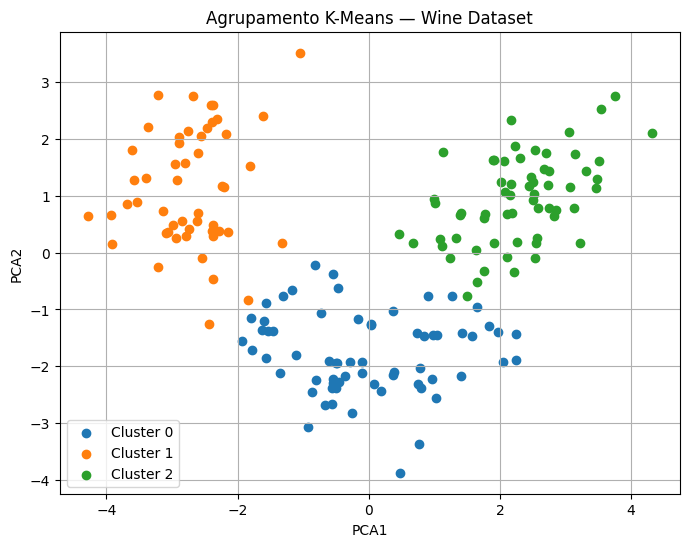

In [15]:
plt.figure(figsize=(8, 6))

for cluster in sorted(resultado["Cluster_KMeans"].unique()):
    grupo = resultado[resultado["Cluster_KMeans"] == cluster]
    plt.scatter(
        grupo["PCA1"],
        grupo["PCA2"],
        label=f"Cluster {cluster}"
    )

plt.title("Agrupamento K-Means — Wine Dataset")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.grid(True)
plt.show()

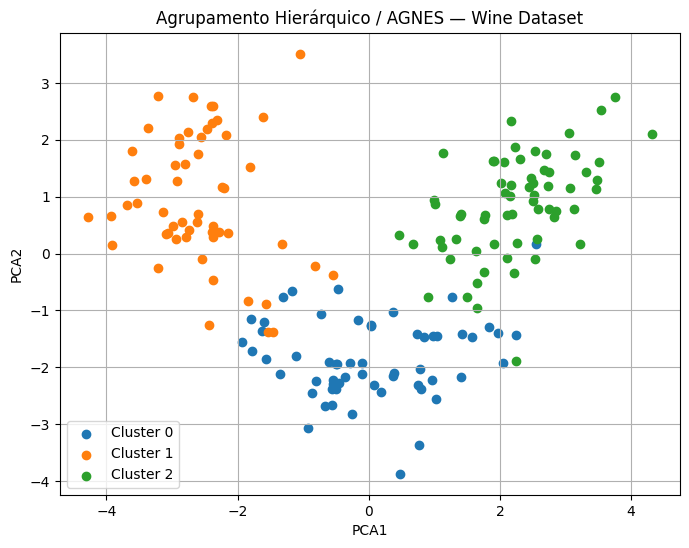

In [16]:
plt.figure(figsize=(8, 6))

for cluster in sorted(resultado["Cluster_AGNES"].unique()):
    grupo = resultado[resultado["Cluster_AGNES"] == cluster]
    plt.scatter(
        grupo["PCA1"],
        grupo["PCA2"],
        label=f"Cluster {cluster}"
    )

plt.title("Agrupamento Hierárquico / AGNES — Wine Dataset")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.grid(True)
plt.show()

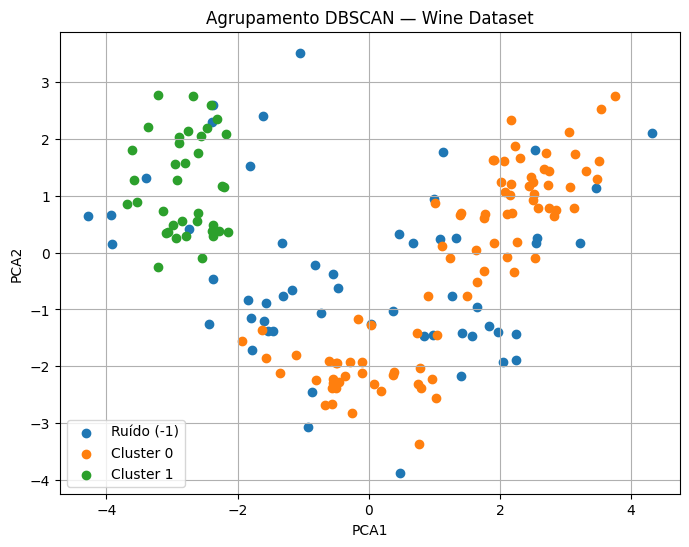

In [17]:
plt.figure(figsize=(8, 6))

for cluster in sorted(resultado["Cluster_DBSCAN"].unique()):
    grupo = resultado[resultado["Cluster_DBSCAN"] == cluster]
    rotulo = "Ruído (-1)" if cluster == -1 else f"Cluster {cluster}"
    plt.scatter(
        grupo["PCA1"],
        grupo["PCA2"],
        label=rotulo
    )

plt.title("Agrupamento DBSCAN — Wine Dataset")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
perfil_kmeans = resultado.groupby("Cluster_KMeans")[wine.feature_names].mean()

perfil_kmeans

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
Cluster_KMeans,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


In [21]:
for cluster, linha in perfil_kmeans.iterrows():
    print(f"\nCluster {cluster}")
    print(f"Álcool médio: {linha['alcohol']:.2f}")
    print(f"Ácido málico médio: {linha['malic_acid']:.2f}")
    print(f"Flavanoides médios: {linha['flavanoids']:.2f}")
    print(f"Intensidade de cor média: {linha['color_intensity']:.2f}")
    print(f"Proline médio: {linha['proline']:.2f}")


Cluster 0
Álcool médio: 12.25
Ácido málico médio: 1.90
Flavanoides médios: 2.05
Intensidade de cor média: 2.97
Proline médio: 510.17

Cluster 1
Álcool médio: 13.13
Ácido málico médio: 3.31
Flavanoides médios: 0.82
Intensidade de cor média: 7.23
Proline médio: 619.06

Cluster 2
Álcool médio: 13.68
Ácido málico médio: 2.00
Flavanoides médios: 3.00
Intensidade de cor média: 5.45
Proline médio: 1100.23


In [22]:
resultado["Classe_Real"] = classes_reais

pd.crosstab(
    resultado["Classe_Real"],
    resultado["Cluster_KMeans"],
    rownames=["Classe real"],
    colnames=["Cluster K-Means"]
)

Cluster K-Means,0,1,2
Classe real,,,
0,0,0,59
1,65,3,3
2,0,48,0


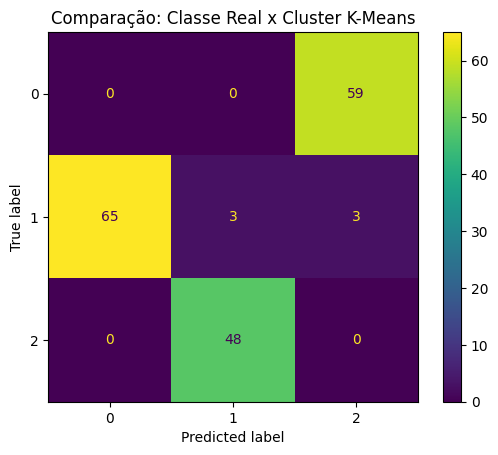

In [23]:
matriz = confusion_matrix(
    resultado["Classe_Real"],
    resultado["Cluster_KMeans"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz
)

disp.plot()
plt.title("Comparação: Classe Real x Cluster K-Means")
plt.show()